In [2]:
! pip install seaborn

In [4]:
 # Libs principais
from model import *
import pandas as pd
# Controle de execução e pastas
import os
# Desativar alguns warnings
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

def VirtualLaneDetector(x,y,virtual_lane_lim,virtual_lane_width):
    virtual_lane = -1
    count = 0

    for list_point in virtual_lane_lim:
        count = count + 1
        func_virtual_lane = PolygonalToFunction(list_point)
        if (y>=func_virtual_lane(x)-0.5*virtual_lane_width) and (y<=func_virtual_lane(x)+0.5*virtual_lane_width):
            virtual_lane = count
            break

    return virtual_lane

In [43]:
df = pd.read_excel(r"C:\Users\thiag\OneDrive\Documents\Repositórios (Local)\traj-analysis\project\Safe Lane\data\result\Consolidado speed_profile.xlsx",sheet_name="bicycle")
# df = df[df["congestion"]==False]
df["interaction"] = df["interaction"].apply(lambda x:"Sim" if x else "Não")

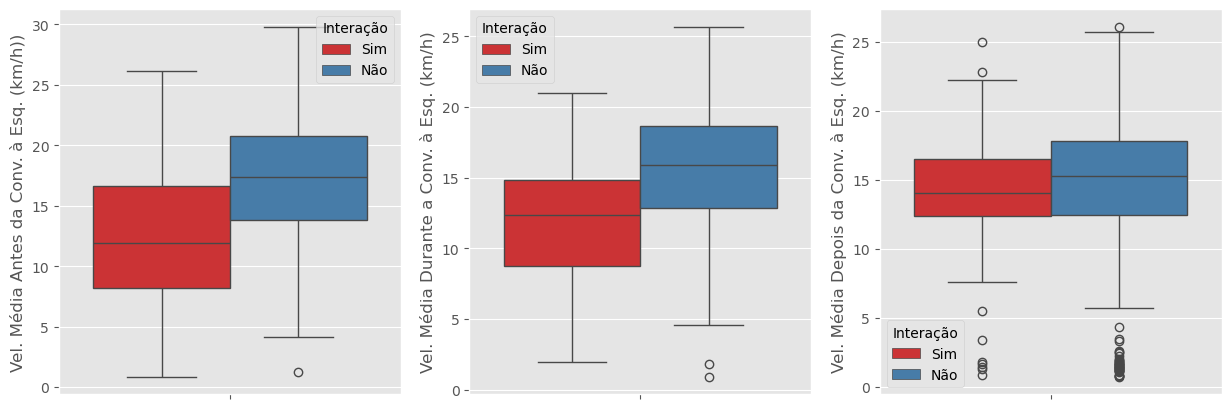

In [41]:
fig, ax = plt.subplots(1,3,figsize=(15, 5)) 

sns.boxplot(data=df,y="average_speed_z1", hue="interaction",ax=ax[0],palette="Set1")
sns.boxplot(data=df,y="average_speed_z2", hue="interaction",ax=ax[1],palette="Set1")
sns.boxplot(data=df,y="average_speed_z3", hue="interaction",ax=ax[2],palette="Set1")

ax[0].set_ylabel("Vel. Média Antes da Conv. à Esq. (km/h))")
ax[1].set_ylabel("Vel. Média Durante a Conv. à Esq. (km/h)")
ax[2].set_ylabel("Vel. Média Depois da Conv. à Esq. (km/h)")

ax[0].legend(title="Interação")
ax[1].legend(title="Interação")
ax[2].legend(title="Interação")

plt.show()

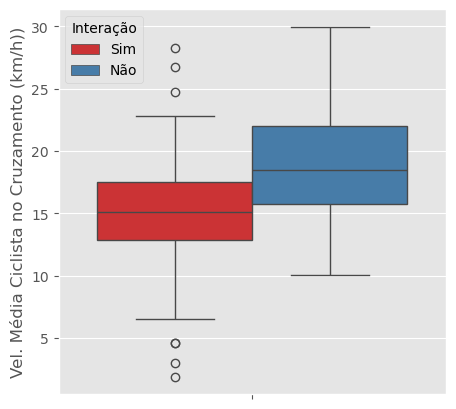

In [47]:
fig, ax = plt.subplots(figsize=(5, 5)) 

sns.boxplot(data=df,y="average_speed", hue="interaction",ax=ax,palette="Set1")


ax.set_ylabel("Vel. Média Ciclista no Cruzamento (km/h))")


ax.legend(title="Interação")

plt.show()

In [14]:
if __name__=="__main__":
    # os.chdir("data_ignore")
    root_file = "data/json"
    all_files = os.listdir(root_file)

    df = {"id_voo":[],"duracao":[],"veiculos":[],"faixas":[]}

    for f in all_files:
        try:
            model = YoloMicroscopicDataProcessing()
            model.ImportFromJSON(os.path.join(root_file,f))

            if "79" in f:
                model.df = model.df[model.df["traffic_lane"].isin([6,7,8,9,10,11])]
            if "10" in f:
                model.df = model.df[model.df["traffic_lane"].isin([2,3,4,5])]
            if "32" in f:
                model.df = model.df[model.df["traffic_lane"].isin([1,2,3,4])]

            df["id_voo"].append(f.split(".")[0])
            df["duracao"].append((model.df["frame"].max()-model.df["frame"].min())/(30*60))
            df["veiculos"].append(len(model.df["id"].unique()))
            df["faixas"].append(len(model.df["traffic_lane"].unique()))
        except Exception as e:
            print(f"Erro {f}")
            print(e)
    
    df = pd.DataFrame(df)

In [15]:
df

,id_voo,duracao,veiculos,faixas
0,10_A_1,13.812778,813,4
1,10_A_2,3.144444,151,4
2,10_A_3,13.833889,705,4
3,10_A_4,6.177222,338,4
4,10_A_5,7.011667,381,4
5,10_B_1,13.807778,577,4
6,10_B_2,6.197222,253,4
7,10_B_3,13.782222,585,4
8,10_B_4,5.106111,242,4
9,10_B_5,5.002778,251,4


In [16]:
df.to_excel("duracao.xlsx")